   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species_code species  
0             0  setosa  
1             0  setosa  
2             0  setosa  
3             0  setosa  
4             0  setosa   

Shape: (150, 6)

Dtypes:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species                  str
dtype: object

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_code         0
species             

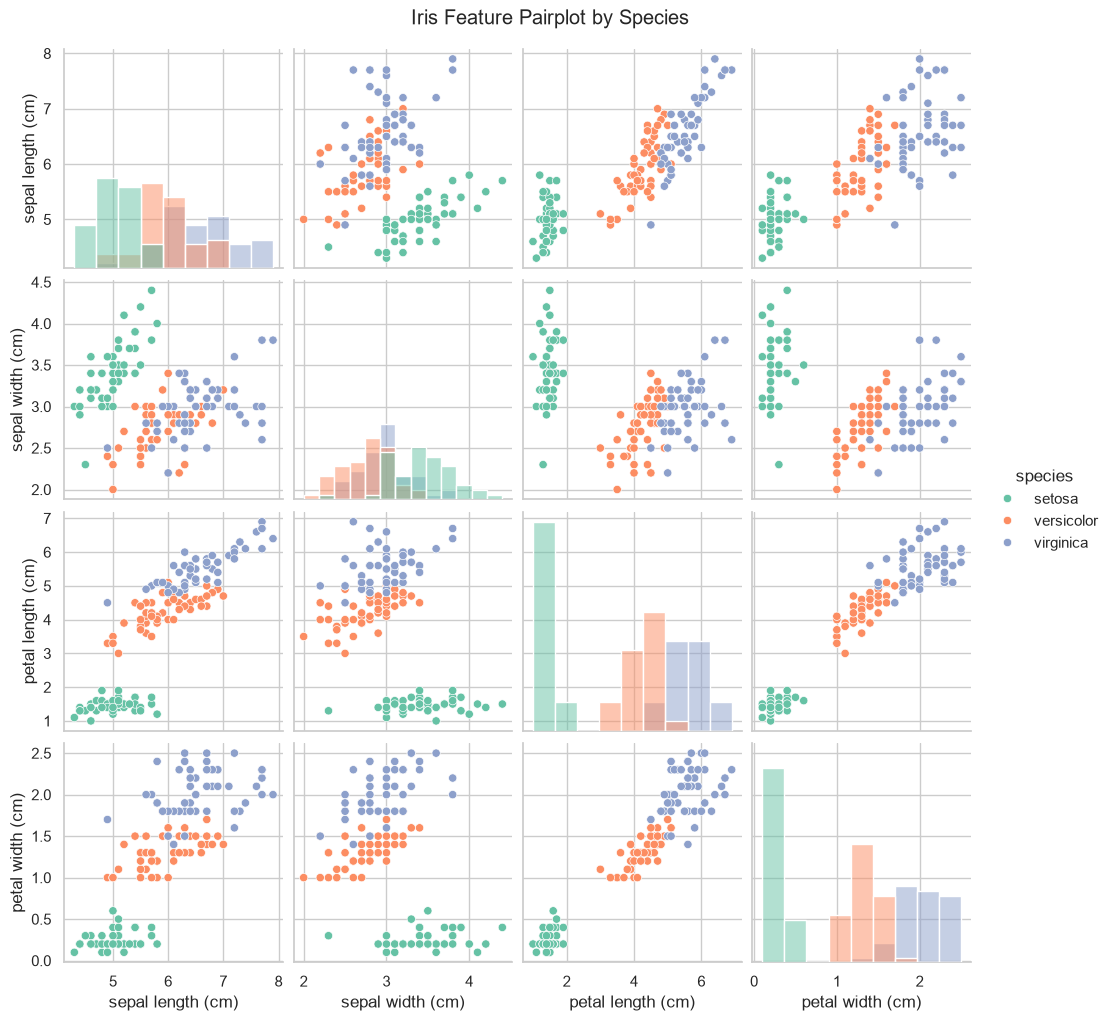

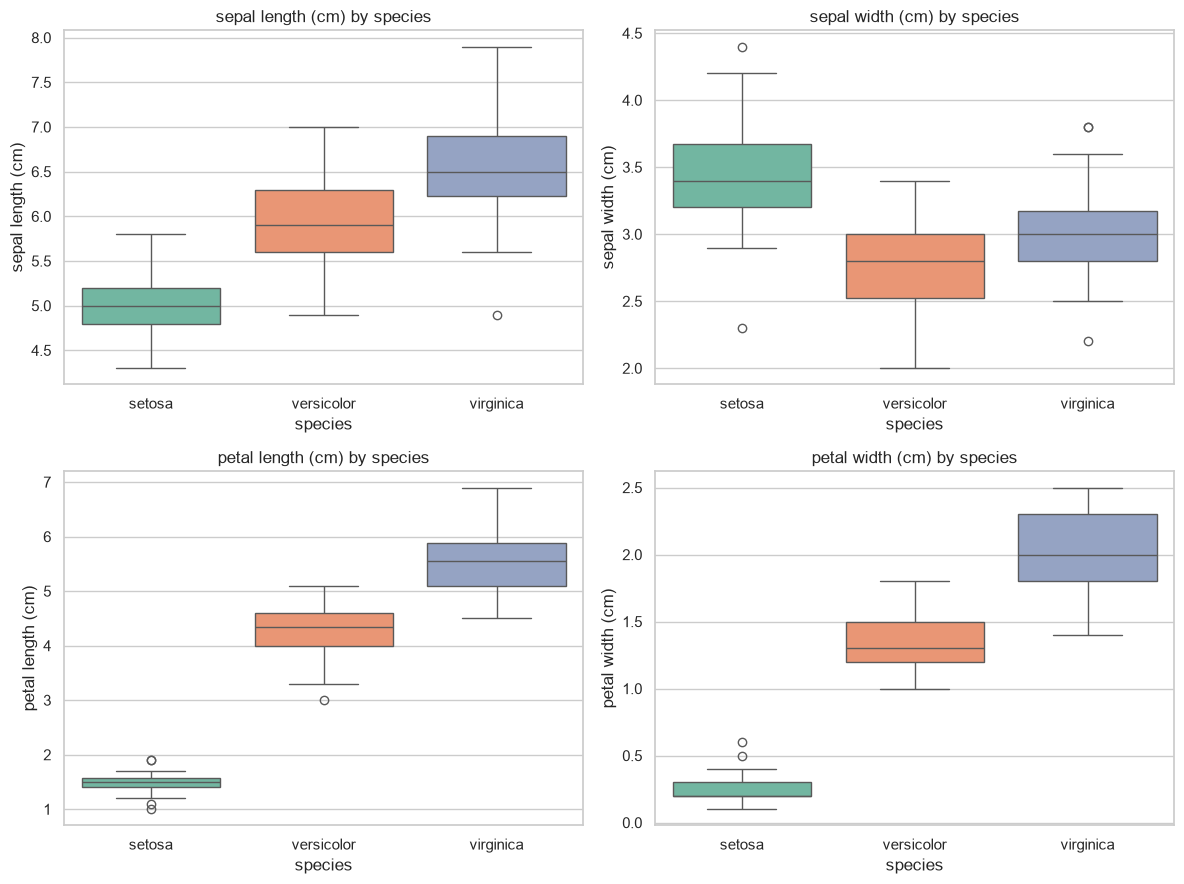

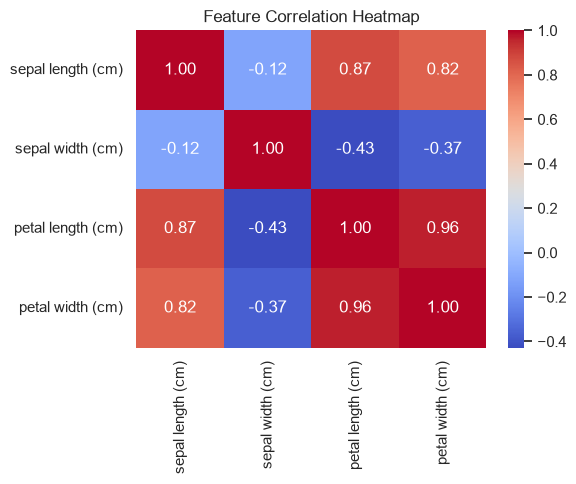

Logistic Regression  —  Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

K-Nearest Neighbours  —  Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Decision Tree  —  Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolo

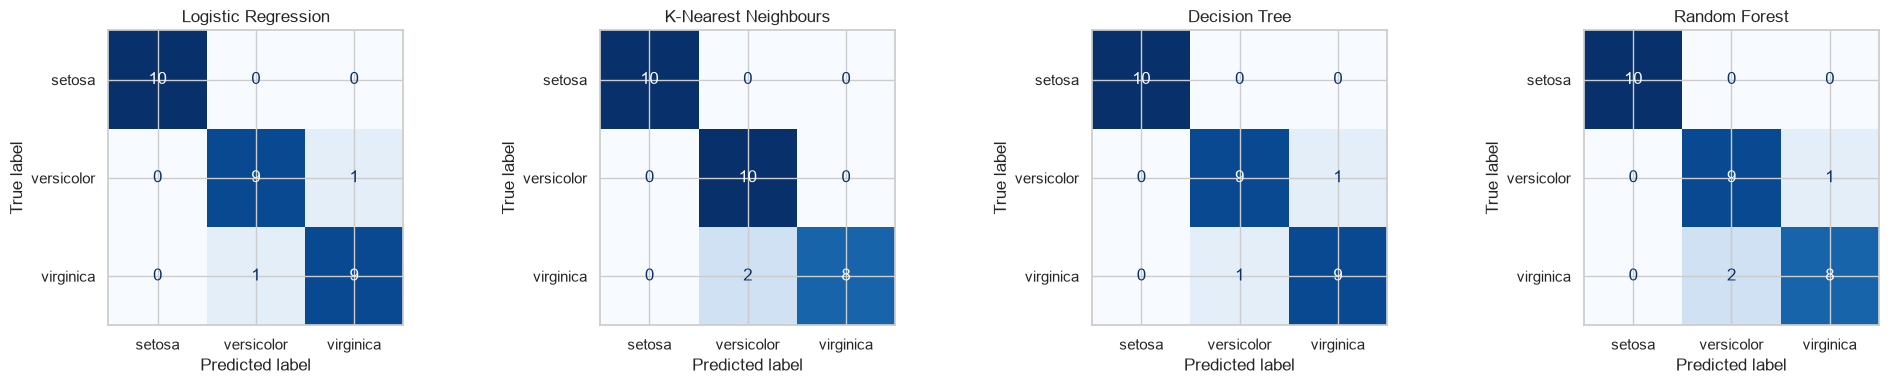

                  Model  Accuracy
0   Logistic Regression  0.933333
1  K-Nearest Neighbours  0.933333
2         Decision Tree  0.933333
3         Random Forest  0.900000


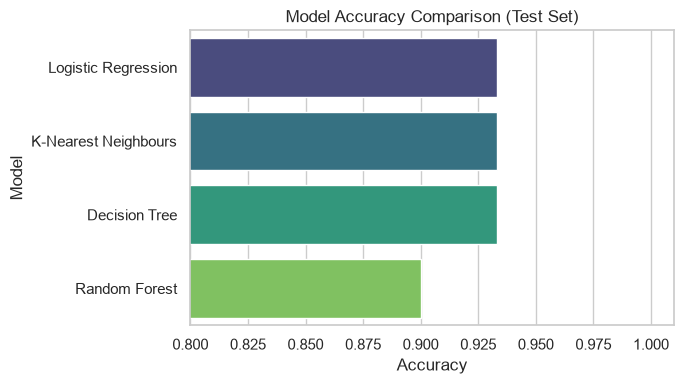


Random Forest feature importances:
 petal length (cm)    0.453793
petal width (cm)     0.412449
sepal length (cm)    0.115873
sepal width (cm)     0.017885
dtype: float64


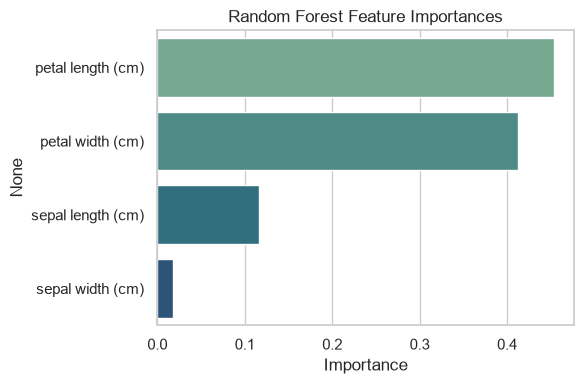


Top accuracy (0.9333) achieved by: ['Logistic Regression', 'K-Nearest Neighbours', 'Decision Tree']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
 
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
 
# -----------------------------------------------------------------------
# 1. Load data
# -----------------------------------------------------------------------
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species_code'] = iris.target
df['species'] = df['species_code'].map(dict(enumerate(iris.target_names)))
print(df.head(), "\n")
 
# -----------------------------------------------------------------------
# 2. EDA
# -----------------------------------------------------------------------
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())
print("\nClass balance:\n", df['species'].value_counts())
print("\nPer-species feature means:\n", df.groupby('species')[iris.feature_names].mean())
 
# -----------------------------------------------------------------------
# 3. Visualisations
# -----------------------------------------------------------------------
sns.pairplot(df, vars=iris.feature_names, hue='species', diag_kind='hist', palette='Set2')
plt.suptitle('Iris Feature Pairplot by Species', y=1.02)
plt.show()
 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x='species', y=feature, hue='species', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{feature} by species')
plt.tight_layout()
plt.show()
 
plt.figure(figsize=(6, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
 
# -----------------------------------------------------------------------
# 4. Feature selection discussion (see printed summary + plots above):
#    Petal length & petal width separate the 3 species almost perfectly
#    (especially Setosa), making them the most discriminative features.
#    Sepal width is the weakest / most overlapping feature across species.
#    We still train on all 4 features below, letting the models weigh
#    them, but petal measurements are expected to dominate importance.
# -----------------------------------------------------------------------
 
# -----------------------------------------------------------------------
# 5. Train / test split (80/20, stratified)
# -----------------------------------------------------------------------
X = df[iris.feature_names]
y = df['species_code']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# -----------------------------------------------------------------------
# 6. Train multiple classifiers
# -----------------------------------------------------------------------
models = {
    "Logistic Regression": (LogisticRegression(max_iter=200, random_state=RANDOM_STATE), True),
    "K-Nearest Neighbours": (KNeighborsClassifier(n_neighbors=5), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
}
 
for name, (model, use_scaled) in models.items():
    model.fit(X_train_scaled if use_scaled else X_train, y_train)
 
# -----------------------------------------------------------------------
# 7. Evaluate each model
# -----------------------------------------------------------------------
results = {}
for name, (model, use_scaled) in models.items():
    X_eval = X_test_scaled if use_scaled else X_test
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
 
    print("=" * 60)
    print(f"{name}  —  Accuracy: {acc:.4f}")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
 
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for ax, (name, (model, use_scaled)) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled if use_scaled else X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()
 
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values()),
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(summary_df)
 
plt.figure(figsize=(7, 4))
sns.barplot(data=summary_df, x="Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.xlim(0.8, 1.01)
plt.title("Model Accuracy Comparison (Test Set)")
plt.tight_layout()
plt.show()
 
# -----------------------------------------------------------------------
# 8. Feature importance (Random Forest) — cross-check vs. Section 4
# -----------------------------------------------------------------------
rf_model = models["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, index=iris.feature_names).sort_values(ascending=False)
print("\nRandom Forest feature importances:\n", importances)
 
plt.figure(figsize=(6, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="crest", legend=False)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
 
# -----------------------------------------------------------------------
# 9. Best model & justification
# -----------------------------------------------------------------------
best_acc = summary_df.iloc[0]["Accuracy"]
tied_models = summary_df[summary_df["Accuracy"] == best_acc]["Model"].tolist()
print(f"\nTop accuracy ({best_acc:.4f}) achieved by: {tied_models}")